<a href="https://colab.research.google.com/github/ayushi226-del/churnzero/blob/main/churn_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'
df = pd.read_csv(file_path)
display(df.head())

,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'
df = pd.read_csv(file_path)
display(df.tail())

,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
8096,141097,0,46,Female,Married,High School,4,Salaried,52564,Middle,...,0,Not Aware,Negative,4146,0.018,0.100,100839.0,31,0.2966,62.2
8097,141098,0,52,Female,Married,High School,1,Business Owner,18000,Low,...,1,Not Aware,Neutral,1154,0.429,0.528,67323.0,22,2.1887,45.1
8098,141099,1,61,Female,Single,Graduate,0,Business Owner,42192,Lower-Middle,...,0,Low,Neutral,2725,0.017,0.151,6378.0,15,0.0000,56.3
8099,141100,0,43,Female,Married,Graduate,3,Salaried,43338,Lower-Middle,...,0,Not Aware,Negative,4609,0.822,0.772,51965.0,25,0.0000,60.5
8100,141101,0,52,Female,Single,Uneducated,3,Retired,32970,Lower-Middle,...,1,Low,Positive,2993,0.622,0.597,48897.0,32,0.4826,39.2


# New

In [ ]:
!pip install -q missingno imbalanced-learn

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler, RobustScaler
from scipy import stats

# Plot aesthetics
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


# Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# ─── Adjust path if your folder structure differs ───
FILE_PATH = '/content/drive/MyDrive/ChurnZero/ChurnZero_Dataset_v1.csv'

df = pd.read_csv(FILE_PATH)
df_original = df.copy()   # keep an untouched backup

print(f'✅ Dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset loaded — 8,101 rows × 98 columns


# Understanding the Problem

In [ ]:
# ── Basic shape & dtypes ──────────────────────────────────────────────────
print('='*60)
print(f'  Rows    : {df.shape[0]:,}')
print(f'  Columns : {df.shape[1]}')
print('='*60)
print('\nColumn data types:')
print(df.dtypes.value_counts())
print('\nFirst 5 rows:')
df.head()

  Rows    : 8,101
  Columns : 98

Column data types:
int64      60
float64    23
object     15
Name: count, dtype: int64

First 5 rows:


,customer_id,churn,age,gender,marital_status,education_level,dependent_count,occupation_type,annual_income,income_band,...,discount_or_fee_waiver_received,competitor_bank_offer_awareness,customer_feedback_sentiment,monthly_income_estimate,credit_utilization_3m_avg,credit_utilization_6m_avg,avg_quarterly_balance,total_digital_logins,debt_to_income_ratio,digital_engagement_index
0,133001,0,36,Female,Married,Unknown,0,Salaried,22256,Low,...,0,Not Aware,Positive,1663,0.839,0.721,28420.0,33,0.0000,55.6
1,133002,1,44,Male,Single,High School,3,Homemaker,66481,Middle,...,1,High,Positive,4979,0.009,0.000,11501.0,19,0.0000,54.5
2,133003,0,46,Male,Married,High School,2,Salaried,98955,Upper-Middle,...,0,Low,Positive,8716,0.104,0.169,11619.0,31,0.0000,43.0
3,133004,0,36,Female,Married,Graduate,2,Retired,26735,Low,...,0,Medium,Neutral,2177,0.438,0.439,26458.0,29,0.5135,57.2
4,133005,0,50,Male,Single,Graduate,1,Salaried,165387,High,...,1,Low,Positive,15401,0.061,0.039,23938.0,22,0.2289,56.1


# Target variable overview

TARGET  |  Count  |  Percentage
--------------------------------------
  Retained |  6,799  |   83.9%
  Churned  |  1,302  |   16.1%


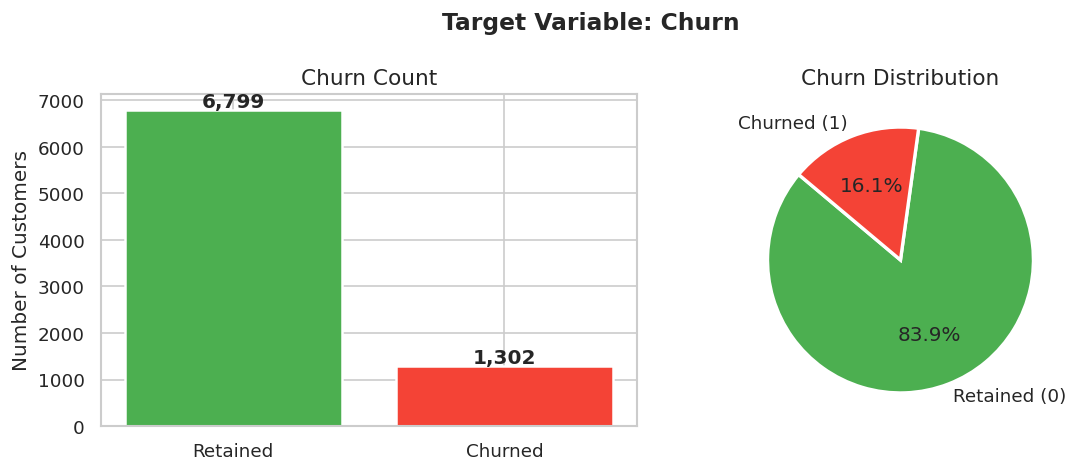

⚠️  Class Imbalance Detected — Churned customers are only ~16%


In [ ]:
# ── Target variable overview ──────────────────────────────────────────────
churn_counts = df['churn'].value_counts()
churn_pct    = df['churn'].value_counts(normalize=True) * 100

print('TARGET  |  Count  |  Percentage')
print('-'*38)
for label in [0, 1]:
    tag = 'Retained' if label == 0 else 'Churned '
    print(f'  {tag} |  {churn_counts[label]:5,}  |  {churn_pct[label]:5.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Retained', 'Churned'], churn_counts.values,
            color=['#4CAF50', '#F44336'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Churn Count')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(churn_counts.values, labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=140, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Churn Distribution')
plt.suptitle('Target Variable: Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('⚠️  Class Imbalance Detected — Churned customers are only ~16%')

# Column Categories

In [ ]:
# ── Column categories ─────────────────────────────────────────────────────
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Numeric  columns : {len(num_cols)}')
print(f'Categorical cols : {len(cat_cols)}')
print(f'\nCategorical columns:\n{cat_cols}')

Numeric  columns : 83
Categorical cols : 15

Categorical columns:
['gender', 'marital_status', 'education_level', 'occupation_type', 'income_band', 'income_category', 'city_tier', 'region', 'customer_segment', 'onboarding_channel', 'relationship_type', 'primary_account_type', 'card_category', 'competitor_bank_offer_awareness', 'customer_feedback_sentiment']


# Statistical summary

In [ ]:
# ── Statistical summary ───────────────────────────────────────────────────
print('Numeric summary (first 10 columns):')
df[num_cols[:10]].describe().T.style.background_gradient(cmap='Blues', axis=1)

Numeric summary (first 10 columns):


,count,mean,std,min,25%,50%,75%,max
customer_id,8101.000000,137051.000000,2338.701598,133001.000000,135026.000000,137051.000000,139076.000000,141101.000000
churn,8101.000000,0.160721,0.367296,0.000000,0.000000,0.000000,0.000000,1.000000
age,8101.000000,46.390199,7.985385,26.000000,41.000000,46.000000,52.000000,73.000000
dependent_count,8101.000000,2.349093,1.297993,0.000000,1.000000,2.000000,3.000000,5.000000
annual_income,8101.000000,60052.874583,35422.472020,18000.000000,31813.000000,51592.000000,76910.000000,241318.000000
tenure_months,8101.000000,36.005555,7.934351,13.000000,32.000000,36.000000,40.000000,56.000000
number_of_products,8101.000000,3.810023,1.554787,1.000000,3.000000,4.000000,5.000000,6.000000
customer_lifetime_value,8101.000000,14102.415556,10603.985218,733.480000,6563.310000,11166.440000,18585.960000,88861.820000
loyalty_program_member,8101.000000,0.542772,0.498198,0.000000,0.000000,1.000000,1.000000,1.000000
referral_count,8101.000000,1.046537,1.076428,0.000000,0.000000,1.000000,2.000000,7.000000


# EDA and Visualisation

Missing value overview:
app_rating_given    4541
dtype: int64


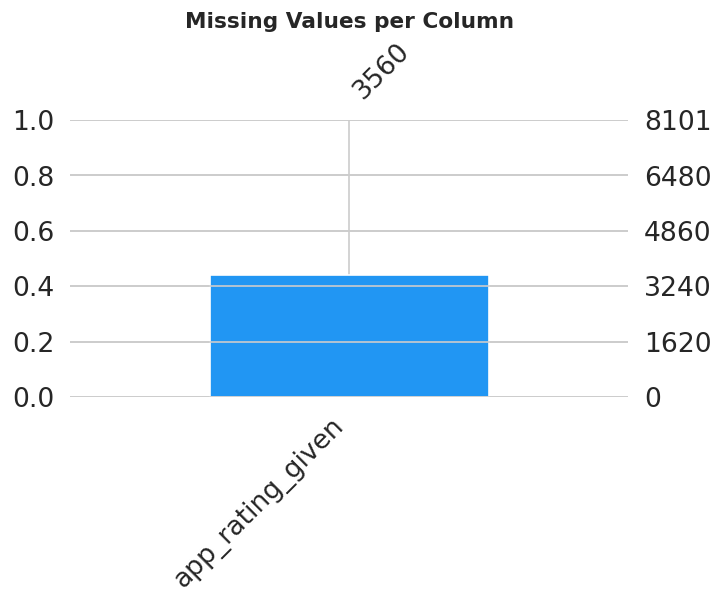

In [ ]:
# ── 3a. Missing value heatmap ─────────────────────────────────────────────
print('Missing value overview:')
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(6, 3))
msno.bar(df[missing.index], color='#2196F3', figsize=(6, 3))
plt.title('Missing Values per Column', fontweight='bold')
plt.show()


# Age & Tenure distribution by Churn




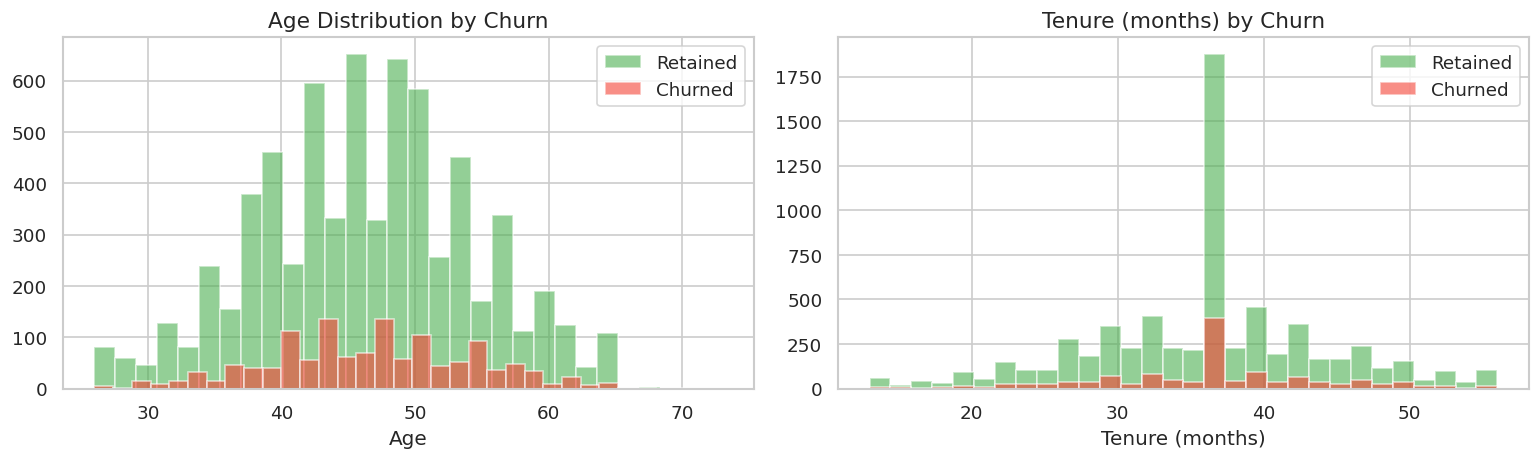

In [ ]:
# ── 3b. Age & Tenure distribution by Churn ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, color in zip([0, 1], ['#4CAF50', '#F44336']):
    subset = df[df['churn'] == label]
    axes[0].hist(subset['age'], bins=30, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned', edgecolor='white')
    axes[1].hist(subset['tenure_months'], bins=30, alpha=0.6, color=color,
                 label='Retained' if label == 0 else 'Churned', edgecolor='white')

axes[0].set_title('Age Distribution by Churn')
axes[0].set_xlabel('Age'); axes[0].legend()
axes[1].set_title('Tenure (months) by Churn')
axes[1].set_xlabel('Tenure (months)'); axes[1].legend()
plt.tight_layout()
plt.show()

# Categorical features vs Churn

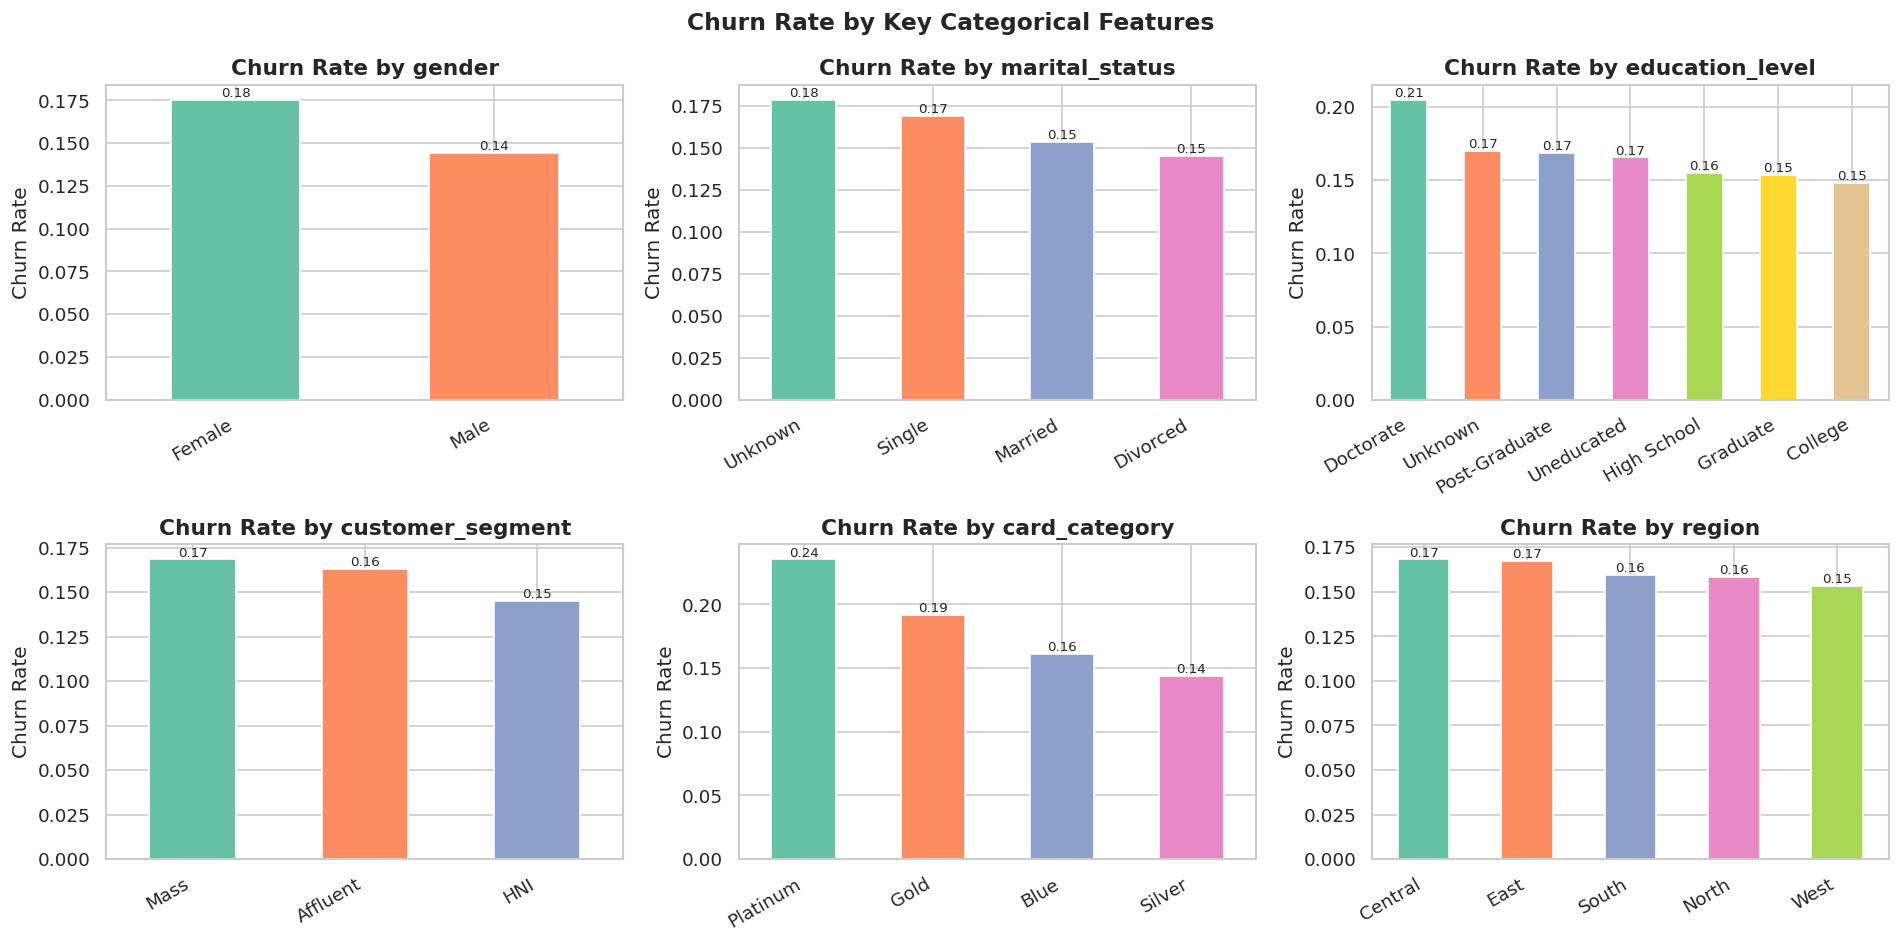

In [ ]:
# ── 3c. Categorical features vs Churn ────────────────────────────────────
top_cats = ['gender', 'marital_status', 'education_level',
            'customer_segment', 'card_category', 'region']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(top_cats):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    churn_rate.plot(kind='bar', ax=axes[i], color=sns.color_palette('Set2'),
                   edgecolor='white', linewidth=1)
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    for bar in axes[i].patches:
        axes[i].annotate(f'{bar.get_height():.2f}',
                         (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                         ha='center', va='bottom', fontsize=8)

plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# HeatMap

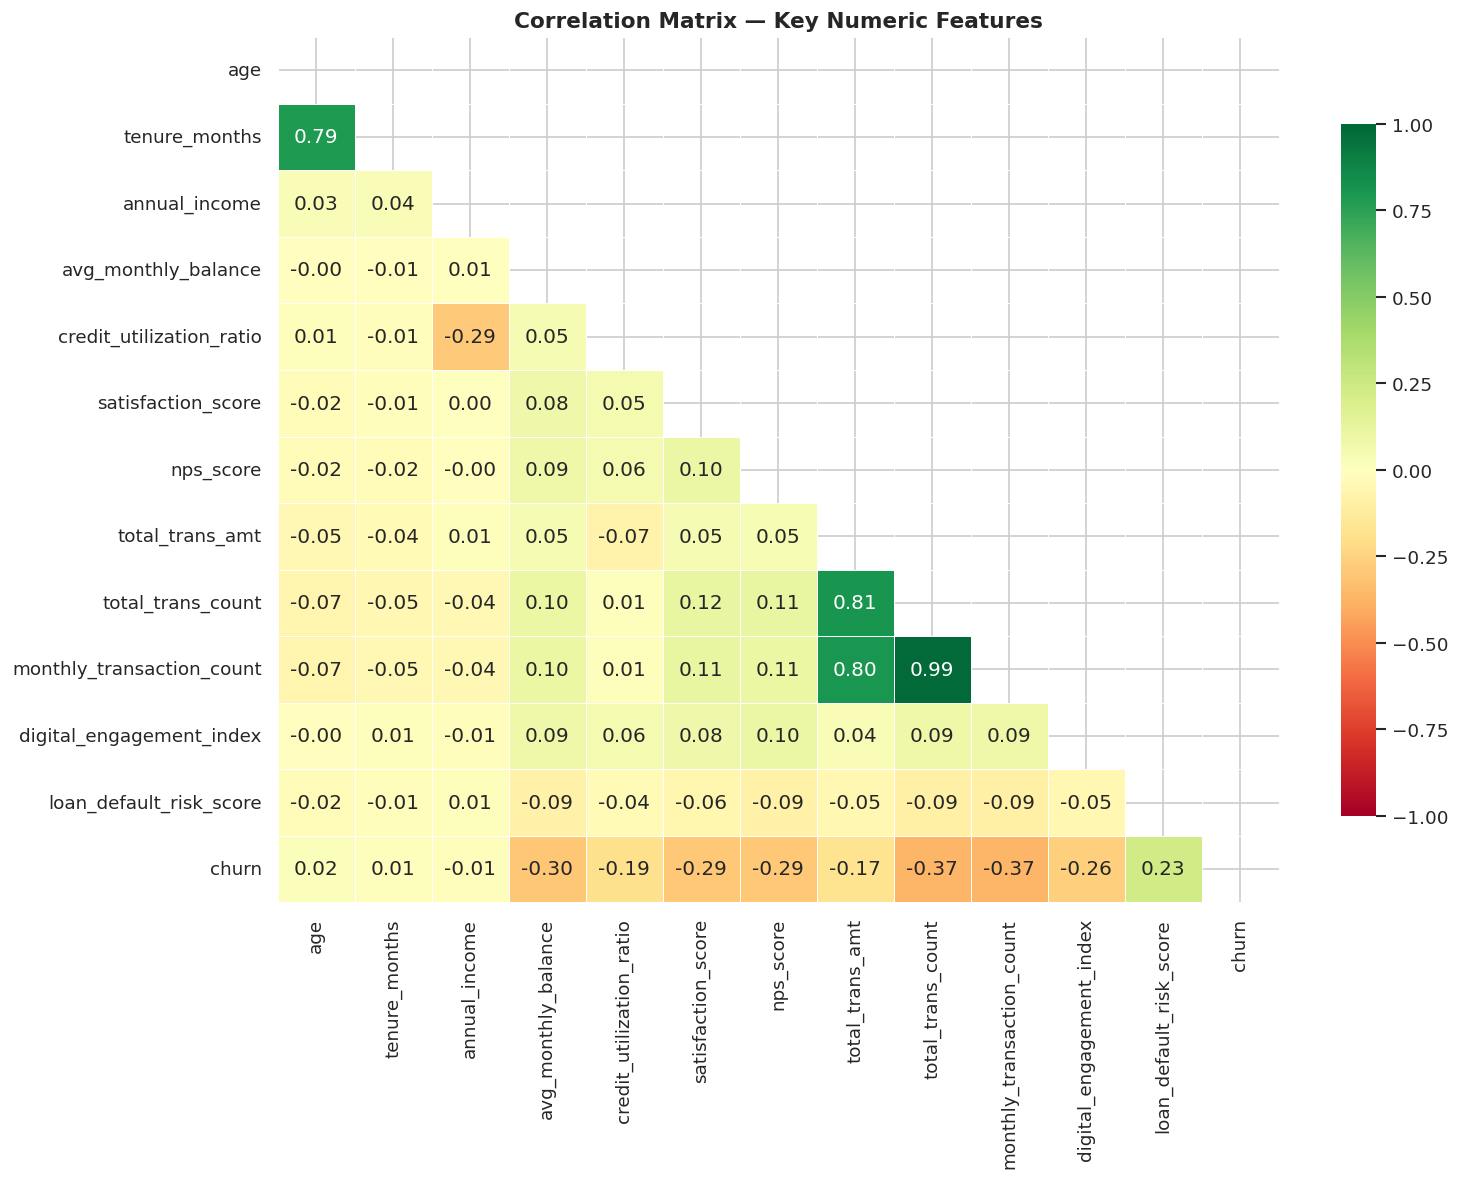

In [ ]:
# ── 3d. Correlation heatmap (key numeric features) ────────────────────────
key_num = ['age', 'tenure_months', 'annual_income', 'avg_monthly_balance',
           'credit_utilization_ratio', 'satisfaction_score', 'nps_score',
           'total_trans_amt', 'total_trans_count', 'monthly_transaction_count',
           'digital_engagement_index', 'loan_default_risk_score', 'churn']

plt.figure(figsize=(13, 10))
corr = df[key_num].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix — Key Numeric Features', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

# Boxplots

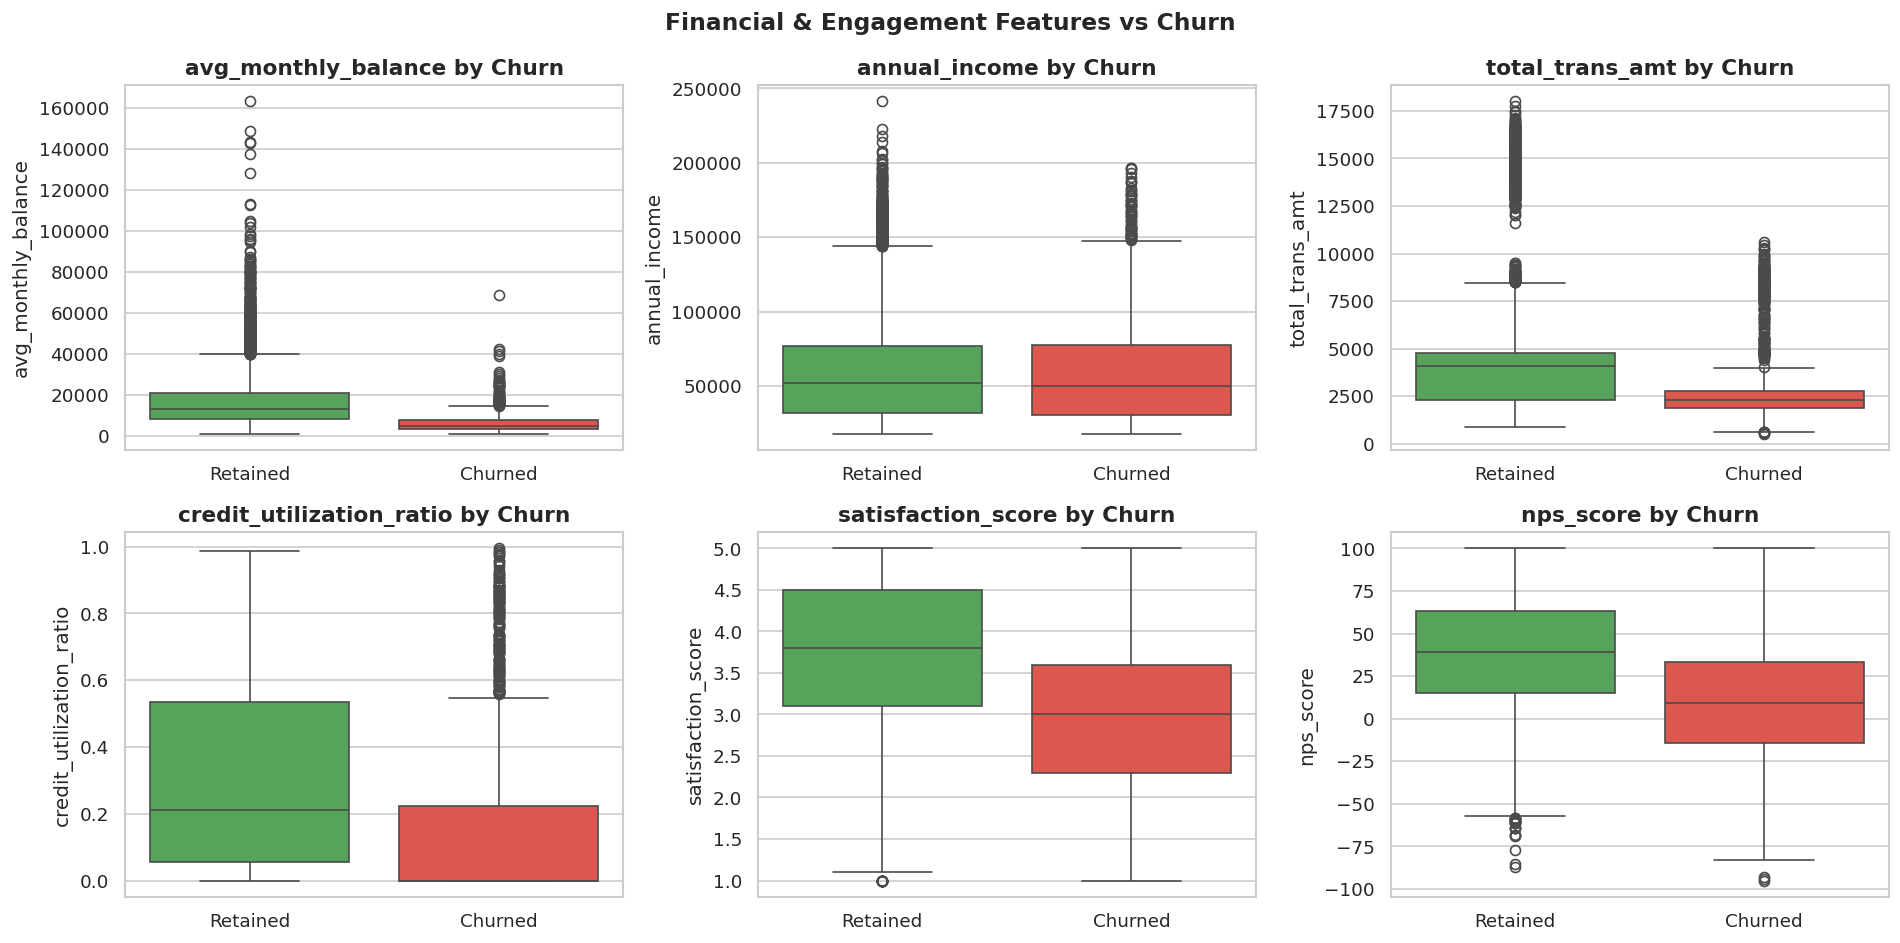

In [ ]:
# ── 3e. Boxplots — financial features by Churn ───────────────────────────
fin_features = ['avg_monthly_balance', 'annual_income', 'total_trans_amt',
                'credit_utilization_ratio', 'satisfaction_score', 'nps_score']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()
for i, feat in enumerate(fin_features):
    sns.boxplot(data=df, x='churn', y=feat, palette=['#4CAF50', '#F44336'],
                ax=axes[i])
    axes[i].set_title(f'{feat} by Churn', fontweight='bold')
    axes[i].set_xticklabels(['Retained', 'Churned'])
    axes[i].set_xlabel('')

plt.suptitle('Financial & Engagement Features vs Churn', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Handling Missing Values

In [22]:
print('Missing values BEFORE:')
print(df.isnull().sum()[df.isnull().sum() > 0])

# app_rating_given — 56% missing → fill with median (ordinal scale 1-5)
df['app_rating_given'] = df['app_rating_given'].fillna(
    df['app_rating_given'].median())

# Generic fallback for any other numeric nulls → median
remaining_num_nulls = df.select_dtypes(include=np.number).columns[
    df.select_dtypes(include=np.number).isnull().any()]
for col in remaining_num_nulls:
    df[col] = df[col].fillna(df[col].median())

# Categorical nulls → mode
remaining_cat_nulls = df.select_dtypes(include='object').columns[
    df.select_dtypes(include='object').isnull().any()]
for col in remaining_cat_nulls:
    df[col] = df[col].fillna(df[col].mode()[0])

print('\nMissing values AFTER:', df.isnull().sum().sum())
print('✅ All missing values handled.')

Missing values BEFORE:
app_rating_given    4541
dtype: int64

Missing values AFTER: 0
✅ All missing values handled.


# Removing Duplicate Data

In [23]:
dupes_before = df.duplicated().sum()
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

# Also check for duplicate customer IDs
dup_ids = df['customer_id'].duplicated().sum()

print(f'Full-row duplicates found   : {dupes_before}')
print(f'Duplicate customer_id found : {dup_ids}')
print(f'Shape after deduplication   : {df.shape}')
print('✅ Duplicate check complete.')

Full-row duplicates found   : 0
Duplicate customer_id found : 0
Shape after deduplication   : (8101, 98)
✅ Duplicate check complete.


# Fixing Incorrect Data

In [24]:
# ── Age: Valid banking customer range 18–90 ───────────────────────────────
invalid_age = ((df['age'] < 18) | (df['age'] > 90)).sum()
print(f'Invalid age values (< 18 or > 90): {invalid_age}')
df['age'] = df['age'].clip(lower=18, upper=90)

# ── Tenure: Cannot be negative ────────────────────────────────────────────
invalid_tenure = (df['tenure_months'] < 0).sum()
print(f'Negative tenure values: {invalid_tenure}')
df['tenure_months'] = df['tenure_months'].clip(lower=0)

# ── Credit utilisation: Must be 0–1 (ratio) ──────────────────────────────
invalid_cr = ((df['credit_utilization_ratio'] < 0) |
              (df['credit_utilization_ratio'] > 1)).sum()
print(f'Invalid credit_utilization_ratio values: {invalid_cr}')
df['credit_utilization_ratio'] = df['credit_utilization_ratio'].clip(0, 1)

# ── Satisfaction / NPS: Enforce valid ranges ──────────────────────────────
df['satisfaction_score'] = df['satisfaction_score'].clip(1, 5)
df['nps_score']           = df['nps_score'].clip(0, 10)

# ── Binary flag columns: Must be 0 or 1 ──────────────────────────────────
flag_cols = [c for c in df.columns if c.endswith('_flag')]
for col in flag_cols:
    bad = (~df[col].isin([0, 1])).sum()
    if bad > 0:
        print(f'  {col}: {bad} invalid flag values → set to 0')
        df[col] = df[col].where(df[col].isin([0, 1]), 0)

print('\n✅ Incorrect data fixed.')

Invalid age values (< 18 or > 90): 0
Negative tenure values: 0
Invalid credit_utilization_ratio values: 0

✅ Incorrect data fixed.


# Handling Outliers

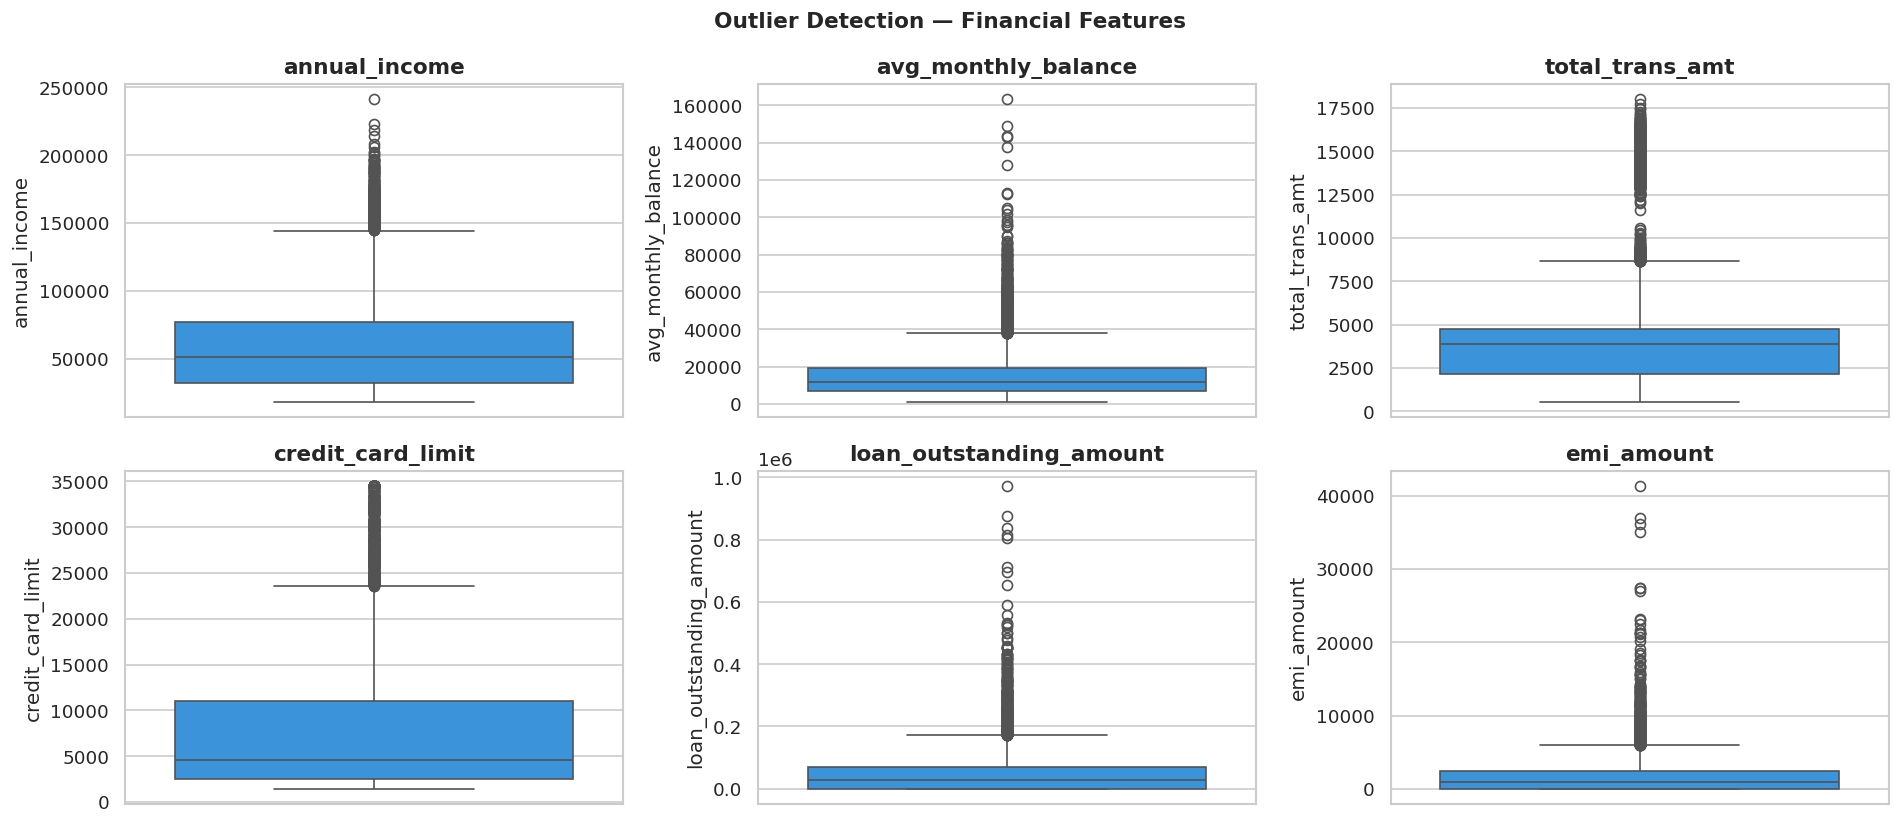

In [25]:
# ── Visualise outliers in key financial columns ───────────────────────────
outlier_cols = ['annual_income', 'avg_monthly_balance', 'total_trans_amt',
                'credit_card_limit', 'loan_outstanding_amount', 'emi_amount']

fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(outlier_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='#2196F3')
    axes[i].set_title(col, fontweight='bold')
plt.suptitle('Outlier Detection — Financial Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()